In [176]:
import pandas as pd

In [177]:
#infos_camadas.csv

dados_camadas = pd.read_csv('infos_camadas.csv')

print(dados_camadas.shape)
print(dados_camadas.dtypes)
print(dados_camadas.head())
print(dados_camadas.describe())

(43405, 9)
pk_aci_corrida             int64
cd_corrida                   str
nu_carregamento          float64
nu_camada                float64
cd_codigo_material           str
qt_peso_carregamento     float64
ds_descricao_material        str
cd_baia                  float64
dt_hora_consumo              str
dtype: object
   pk_aci_corrida cd_corrida  nu_carregamento  nu_camada cd_codigo_material  \
0          653467      N8707              3.0        1.0               GUSL   
1          653467      N8707              1.0        3.0               SUGU   
2          653467      N8707              1.0        9.0               MISM   
3          653467      N8707              1.0       10.0               OXIC   
4          653467      N8707              1.0       13.0               GUSS   

   qt_peso_carregamento ds_descricao_material  cd_baia  \
0               30800.0          GUSA LIQUIDO      NaN   
1                3250.0        SUCATA DE GUSA      6.0   
2                5270.0      

In [178]:
# infos_materiais.csv

dados_materiais = pd.read_csv('infos_materiais.csv')

print(dados_materiais.shape)
print(dados_materiais.dtypes)
print(dados_materiais.head())

(30, 4)
Metálico                     str
Energia Elétrica         float64
Densidade t/m3               str
Rendimento Metálico %        str
dtype: object
  Metálico  Energia Elétrica Densidade t/m3 Rendimento Metálico %
0     ESPS             343.0           0,40                  0,93
1     RECA             359.0           2,60                  0,80
2     PAEP             343.0           0,70                  0,93
3  7071955               NaN            CAL                   NaN
4     PACB             300.0           0,54                  0,83


In [179]:
# VariavelResposta.csv

dados_resposta = pd.read_csv('VariavelResposta.csv')

print(dados_resposta.shape)
print(dados_resposta.dtypes)
print(dados_resposta.head())
print(dados_resposta.describe())

(1799, 7)
cd_corrida                                     str
is_carga_alta_carregamento_1                 int64
is_carga_alta_carregamento_2                 int64
qt_segundos_duracao_parada_carregamento_1    int64
qt_segundos_duracao_parada_carregamento_2    int64
is_carga_alta                                int64
qt_segundos_parada_carga_alta                int64
dtype: object
  cd_corrida  is_carga_alta_carregamento_1  is_carga_alta_carregamento_2  \
0      O7417                             0                             0   
1      O7419                             0                             0   
2      O7382                             1                             0   
3      O7389                             0                             0   
4      O7379                             0                             0   

   qt_segundos_duracao_parada_carregamento_1  \
0                                          0   
1                                          0   
2                 

In [180]:
# dicionario_tipo_material.csv

dados_dicionario = pd.read_csv('dicionario_tipo_material.csv')

print(dados_dicionario.shape)
print(dados_dicionario.dtypes)
print(dados_dicionario.head())

(24, 3)
cd_codigo_material       str
ds_descricao_material    str
tp_material              str
dtype: object
  cd_codigo_material      ds_descricao_material tp_material
0               SHRE                   SHREDDER        Leve
1               ESPS     ESTAMPARIA PRETA SOLTA        Leve
2               CAVA              CAVACO DE ACO        Leve
3               RETL  SUCATA GERADA NO PROCESSO        Leve
4               PACB    PACOTE DE CHAPARIA BODE        Leve


In [181]:
base = dados_camadas.merge(dados_dicionario, on='cd_codigo_material', how='left')
base = base.merge(dados_materiais, left_on='cd_codigo_material', right_on='Metálico', how='left')

In [182]:
base.to_csv('base.csv', index=False)

In [183]:
print(dados_camadas.shape[0])   # linhas originais
print(base.shape[0])            # linhas depois do merge

43405
43405


In [184]:
base.isnull().sum()

pk_aci_corrida                0
cd_corrida                    0
nu_carregamento               0
nu_camada                     0
cd_codigo_material            0
qt_peso_carregamento          0
ds_descricao_material_x       0
cd_baia                    1563
dt_hora_consumo            1715
ds_descricao_material_y       0
tp_material                   0
Metálico                     10
Energia Elétrica             10
Densidade t/m3               10
Rendimento Metálico %        10
dtype: int64

In [185]:
# Exibe as estatísticas descritivas das variáveis numéricas do DataFrame 'base'.
base.describe()

,pk_aci_corrida,nu_carregamento,nu_camada,qt_peso_carregamento,cd_baia,Energia Elétrica
count,43405.000000,43405.000000,43405.000000,43405.000000,41842.000000,43395.000000
mean,658804.849050,1.433959,6.726806,5053.095150,15.013876,353.863464
std,3176.386147,0.565455,4.201250,5922.871828,8.003315,24.175640
min,653467.000000,1.000000,1.000000,0.000000,1.000000,293.000000
25%,655862.000000,1.000000,3.000000,2910.000000,8.000000,350.000000
50%,658511.000000,1.000000,6.000000,4120.000000,14.000000,350.000000
75%,661981.000000,2.000000,10.000000,5290.000000,23.000000,365.000000
max,664142.000000,3.000000,20.000000,48500.000000,35.000000,405.000000


In [186]:
# Boxplot para visualizar outliers em todas as variáveis numéricas
import matplotlib.pyplot as plt

In [187]:
# Faz com que possamos ver todas as linhas, sem "..."

pd.set_option('display.max_rows', None)

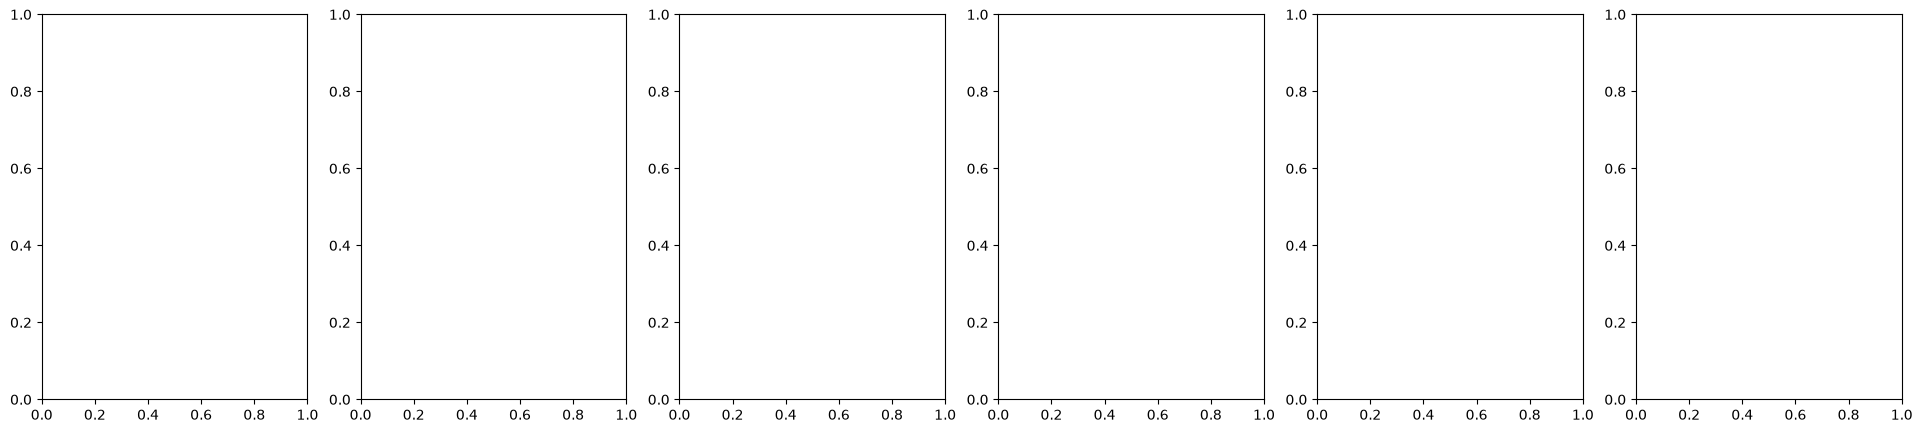

In [188]:
numericas = base.select_dtypes(include='number').columns
fig, axes = plt.subplots(nrows=1, ncols=len(numericas), figsize=(4*len(numericas), 5))

In [189]:
for ax, col in zip(axes, numericas):
    base.boxplot(column=col, ax=ax)
    ax.set_title(col)

In [191]:
# Identificar outliers usando IQR (Interquartile Range)
def detectar_outliers_iqr(base, coluna):
    Q1 = base[coluna].quantile(0.25)
    Q3 = base[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = base[(base[coluna] < limite_inf) | (base[coluna] > limite_sup)]
    return outliers, limite_inf, limite_sup

In [192]:
outliers, lim_inf, lim_sup = detectar_outliers_iqr(base, 'qt_peso_carregamento')
print(f'Outliers encontrados: {len(outliers)}')
print(f'Intervalo esperado: [{lim_inf:.2f}, {lim_sup:.2f}]')

Outliers encontrados: 1719
Intervalo esperado: [-660.00, 8860.00]


In [193]:
print(outliers['qt_peso_carregamento'].to_string())

0        30800.0
33       30800.0
48       35500.0
78       36400.0
102      38500.0
152      33700.0
172      30000.0
197      40700.0
198      30600.0
216      32300.0
250      32300.0
251      34000.0
260      32200.0
315      34000.0
445      30300.0
468      32600.0
491      31800.0
512      33500.0
542      34700.0
573      24200.0
584      35500.0
601      38500.0
630      10160.0
631      30100.0
643      30000.0
677      30800.0
693      32500.0
717      35100.0
750      31000.0
771      34400.0
788      36300.0
794      34500.0
795      39100.0
821      36800.0
848      32100.0
883      32500.0
909      34100.0
924      33000.0
940      32800.0
973      30000.0
988      34200.0
1007      9950.0
1008     34600.0
1040     43200.0
1057     30000.0
1097     32000.0
1109     30000.0
1121     35500.0
1166     43200.0
1167     30500.0
1227     31500.0
1244     30000.0
1276     31100.0
1289     34500.0
1313     34000.0
1314     36000.0
1377     36000.0
1382     35500.0
1398     34000

In [194]:
variavel = pd.read_csv('VariavelResposta.csv')

outliers, lim_inf, lim_sup = detectar_outliers_iqr(variavel, 'qt_segundos_duracao_parada_carregamento_1')
print(f'Outliers encontrados: {len(outliers)}')
print(f'Intervalo esperado: [{lim_inf:.2f}, {lim_sup:.2f}]')

Outliers encontrados: 258
Intervalo esperado: [0.00, 0.00]


In [201]:
print(outliers['qt_segundos_duracao_parada_carregamento_1'].to_string())

7          0
9          0
11        52
13         0
15         0
28         0
39         0
54       312
59         0
65         0
74         0
78         0
105      381
122      163
124      617
138      291
139      207
146        0
148        0
150      641
173      714
185        0
187        0
201        0
218        0
224      247
227      437
230      643
243        0
265        0
268        0
281        0
290       97
296        0
300        0
304        0
310        0
318      524
323        0
344        0
367      764
370        0
378      269
397        0
402        0
407        0
454        0
457        0
473      338
474      428
475        0
476      414
484      219
489      351
492        0
493      366
494      210
504      299
505        0
509      300
513      224
520      392
533        0
537      206
541        0
582        0
586        0
591        0
603        0
617        0
634      357
636        0
639      499
649      225
665      209
666        0
671        0

In [195]:
outliers, lim_inf, lim_sup = detectar_outliers_iqr(variavel, 'qt_segundos_duracao_parada_carregamento_2')
print(f'Outliers encontrados: {len(outliers)}')
print(f'Intervalo esperado: [{lim_inf:.2f}, {lim_sup:.2f}]')

Outliers encontrados: 308
Intervalo esperado: [0.00, 0.00]


In [202]:
print(outliers['qt_segundos_duracao_parada_carregamento_2'].to_string())

7        222
9        282
11       183
13       444
15       217
28       347
39       383
54         0
59       812
65       714
74       411
78       753
105        0
122       38
124        0
138        0
139        0
146      416
148      365
150        0
173        0
185      502
187      213
201      635
218      350
224        0
227        0
230      384
243      607
265      245
268      357
281      202
290      266
296      240
300      243
304      339
310      229
318        0
323      330
344      357
367        0
370      248
378        0
397      252
402      252
407      863
454      632
457      283
473        0
474        0
475      304
476        0
484        0
489      231
492      392
493        0
494      134
504        0
505      248
509        0
513        0
520        0
533      410
537        0
541      711
582      212
586      268
591      372
603      353
617      536
634        0
636      392
639        0
649        0
665        0
666      470
671      614

In [196]:
outliers, lim_inf, lim_sup = detectar_outliers_iqr(variavel, 'qt_segundos_parada_carga_alta')
print(f'Outliers encontrados: {len(outliers)}')
print(f'Intervalo esperado: [{lim_inf:.2f}, {lim_sup:.2f}]')

Outliers encontrados: 249
Intervalo esperado: [-118.50, 197.50]


In [203]:
print(outliers['qt_segundos_parada_carga_alta'].to_string())

7        222
9        282
11       235
13       444
15       217
28       347
39       383
54       312
59       812
65       714
74       411
78       753
105      381
122      201
124      617
138      291
139      207
146      416
148      365
150      641
173      714
185      502
187      213
201      635
218      350
224      247
227      437
230     1027
243      607
265      245
268      357
281      202
290      363
296      240
300      243
304      339
310      229
318      524
323      330
344      357
367      764
370      248
378      269
397      252
402      252
407      863
454      632
457      283
473      338
474      428
475      304
476      414
484      219
489      582
492      392
493      366
494      344
504      299
505      248
509      300
513      224
520      392
533      410
537      206
541      711
582      212
586      268
591      372
603      353
617      536
634      357
636      392
639      499
649      225
665      209
666      470
671      614

In [204]:
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>